In [1]:
base_path = '/Users/minhapark/Desktop/sql_project/archive'

In [4]:
plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus']=False

In [5]:
import pandas as pd

In [6]:
customers_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_customers_dataset.csv')
geolocation_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_geolocation_dataset.csv')
items_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_order_items_dataset.csv')
payments_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_order_payments_dataset.csv')
reviews_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_order_reviews_dataset.csv')
orders_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_orders_dataset.csv')
products_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_products_dataset.csv')
sellers_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_sellers_dataset.csv')

In [7]:
orders_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 1. 현재 배송 시스템 상황 파악

- 현재 배송시스템의 상황을 보기 위해서  지연/조기 배송 여부를 파악해 봄
- 배송지연 고객이 많았고 이 부분을 보여주기 위해 파이차트로 시각화 진행
- 평점이 낮은(1,2점) 리뷰 메세지를 분석해 배송지연으로 인한 낮은 평점인지 파악
- 약 평점 1점 고객의 26%가 배송지연문제를 겪은것으로 파악 (시각화 필요)

1. (실제 배송일 – 예상 배송일) → 지연/조기 배송 여부 라벨링
   - 배송지연 고객 비율 파이차트로 배송지연 고객의 비율을 보여줌.

In [8]:
orders_df['order_delivered_customer_date'].isna().sum()

np.int64(2965)

In [9]:
orders_df['order_estimated_delivery_date'].isna().sum()

np.int64(0)

### null 값 처리 - 배송 완료건만 필터링

In [10]:
delivered_df = orders_df[orders_df['order_delivered_customer_date'].notna()].copy()

### 날짜 차이 계산 | 라벨링

In [11]:
date_cols = [
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    delivered_df[col] = pd.to_datetime(delivered_df[col])

delivered_df['delivery_diff'] =  (delivered_df['order_delivered_customer_date'] - delivered_df['order_estimated_delivery_date']
).dt.days

delivered_df["delivery_status"] = delivered_df["delivery_diff"].apply(lambda x: "지연" if x > 0 else "조기")

In [12]:
delivered_df['delivery_diff']

0        -8
1        -6
2       -18
3       -13
4       -10
         ..
99436   -11
99437    -2
99438    -6
99439   -21
99440   -18
Name: delivery_diff, Length: 96476, dtype: int64

In [13]:
delivered_df["delivery_status"].head(5)

0    조기
1    조기
2    조기
3    조기
4    조기
Name: delivery_status, dtype: object

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

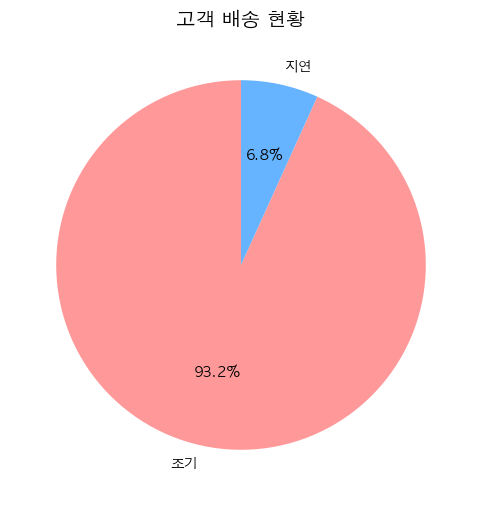

In [16]:
status_counts = delivered_df["delivery_status"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    status_counts,
    labels = status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=["#ff9999","#66b3ff"]
)

plt.title('고객 배송 현황', fontsize=14)
plt.show()

In [36]:
orders_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [19]:
# orders와 reviews 합치기 (order_id 기준)
merged_df = pd.merge(orders_df, reviews_df, on="order_id", how="inner")

# 배송 완료건만 필터링
merged_df = merged_df[merged_df['order_delivered_customer_date'].notna()].copy()

# 날짜 차이 계산
merged_df['delivery_diff'] = (
    pd.to_datetime(merged_df['order_delivered_customer_date']) - 
    pd.to_datetime(merged_df['order_estimated_delivery_date'])
).dt.days

# 배송 상태 라벨링
merged_df['delivery_status'] = merged_df['delivery_diff'].apply(
    lambda x: "지연" if x > 0 else "조기"
)

# 리뷰 점수 1점,2점 준 고객만 필터링
low_core = merged_df[(merged_df['review_score'] == 1) | (merged_df['review_score'] == 2)]

# 배송 상태 비율 계산
status_counts = low_core['delivery_status'].value_counts(normalize=True) * 100
print(status_counts)

delivery_status
조기    67.611336
지연    32.388664
Name: proportion, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

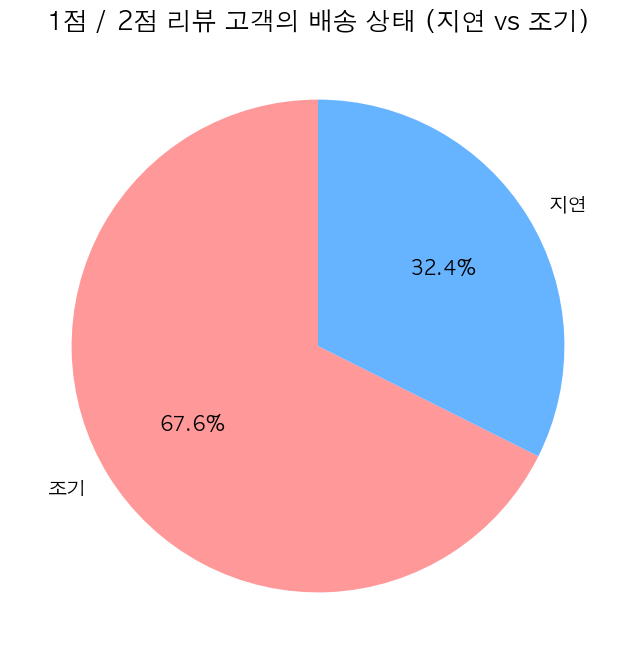

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=["#ff9999","#66b3ff"],
    textprops = {'fontsize': 14}
)
plt.title("1점 / 2점 리뷰 고객의 배송 상태 (지연 vs 조기)", fontsize=18)
plt.savefig('1점, 2점 리뷰 고객의 배송 상태')
plt.show

In [26]:
products_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [27]:
items_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [28]:
orders_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


## 카테고리별 배송 현황

In [8]:
# 날짜 컬럼을 datetime으로 변환
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])


orders_df['delivery_diff'] = (orders_df['order_delivered_customer_date'] - orders_df['order_estimated_delivery_date']).dt.days
orders_df['delivery_status'] = orders_df['delivery_diff'].apply(
    lambda x: "지연" if x > 0 else "제때/조기"
)                          

In [9]:
merged_df = orders_df.merge(items_df, on='order_id', how='inner').merge(products_df, on='product_id', how='inner')

In [10]:
merged_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_diff,delivery_status,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,제때/조기,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,제때/조기,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,제때/조기,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,제때/조기,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,제때/조기,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [11]:
# 부피(cm³) 계산
merged_df['volume_cm3'] = (
    merged_df['product_length_cm'] * 
    merged_df['product_height_cm'] * 
    merged_df['product_width_cm']
)

In [39]:
# 카테고리별 배송 지연률
category_delay = merged_df.groupby('product_category_name')['delivery_status'].apply(lambda x: (x == '지연').mean()).sort_values(ascending=False)

category_delay.head(10)

product_category_name
casa_conforto_2                   0.133333
moveis_colchao_e_estofado         0.131579
audio                             0.115385
artigos_de_natal                  0.098039
casa_conforto                     0.092166
fashion_underwear_e_moda_praia    0.091603
livros_tecnicos                   0.078652
moveis_escritorio                 0.078652
eletronicos                       0.074810
bebes                             0.074715
Name: delivery_status, dtype: float64

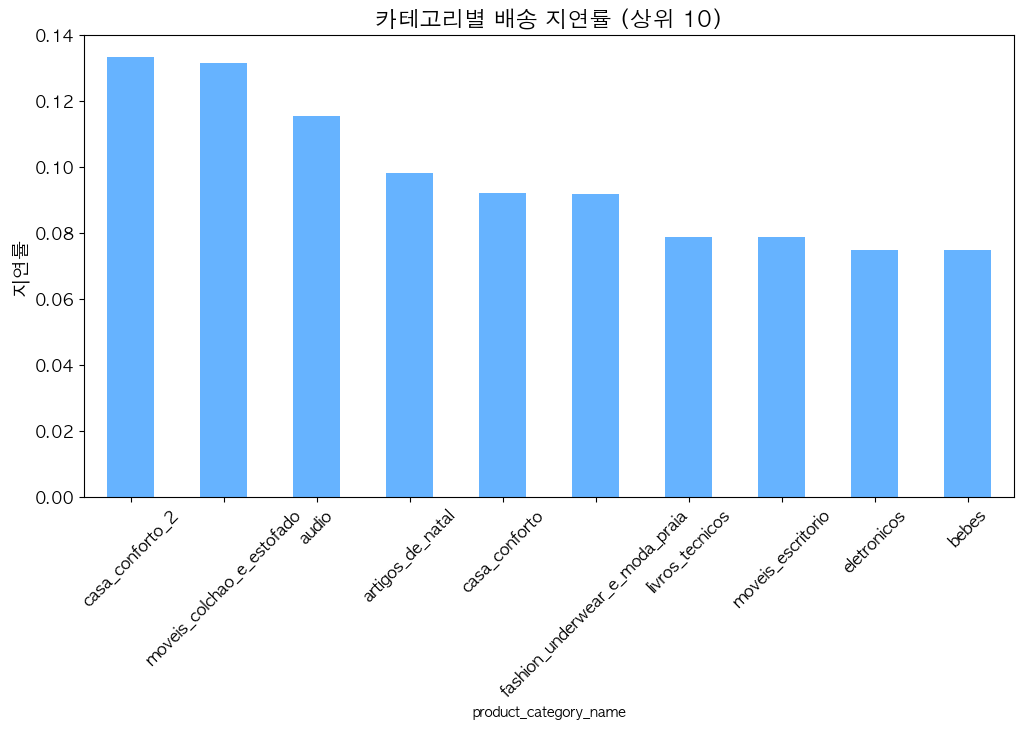

In [44]:
top10 = category_delay.head(10)

plt.figure(figsize=(12,6))
top10.plot(kind='bar', color="#66b3ff")
plt.title("카테고리별 배송 지연률 (상위 10)", fontsize=16)
plt.ylabel("지연률", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [47]:
# 무게 / 부피 구간별 지연률

# 무게구간 (5분위수)
weight_delay = merged_df.groupby(pd.qcut(merged_df['product_weight_g'], 4))['delivery_status'].apply(
    lambda x: (x == "지연").mean()
)

weight_delay

# 부피 구간 (5분위수)
volume_delay = merged_df.groupby(pd.qcut(merged_df['volume_cm3'], 4))['delivery_status'].apply(
    lambda x: (x == "지연").mean()
)
volume_delay

/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_1563/2835904783.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weight_delay = merged_df.groupby(pd.qcut(merged_df['product_weight_g'], 4))['delivery_status'].apply(
/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_1563/2835904783.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volume_delay = merged_df.groupby(pd.qcut(merged_df['volume_cm3'], 4))['delivery_status'].apply(


volume_cm3
(167.999, 2851.5]      0.062291
(2851.5, 6480.0]       0.063749
(6480.0, 18375.0]      0.061571
(18375.0, 296208.0]    0.070419
Name: delivery_status, dtype: float64

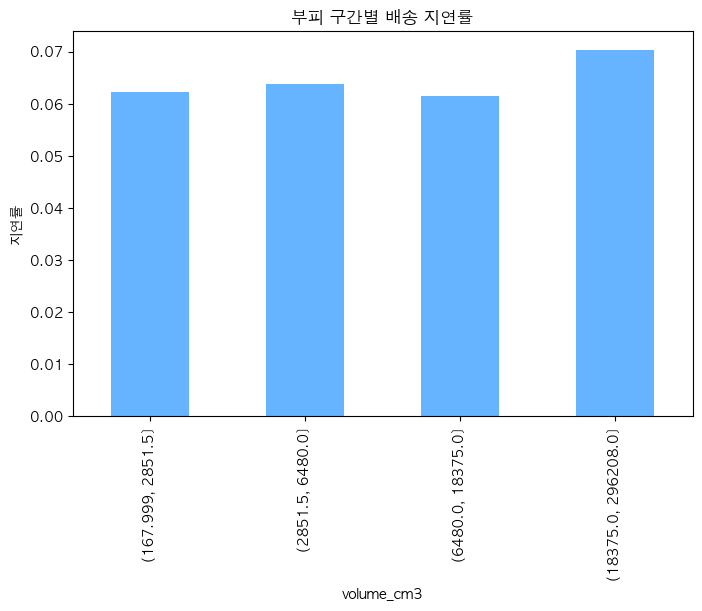

In [51]:
volume_delay.plot(kind='bar', figsize=(8,5), color='#66b3ff')
plt.title('부피 구간별 배송 지연률')
plt.ylabel('지연률')
plt.savefig('부피 구간별 배송 지연률', dpi=300)
plt.show()

In [54]:
# 고객별 평균 배송일수
customer_delivery = orders_df.groupby('customer_id')['delivery_diff'].mean().reset_index()
customer_delivery.rename(columns={'delivery_diff': 'avg_delivery_days'}, inplace=True)

In [61]:
from sklearn.cluster import KMeans

# NaN 있는 고객 제거
customer_delivery_clean = customer_delivery.dropna(subset=['avg_delivery_days'])

X = customer_delivery_clean[['avg_delivery_days']]

kmeans = KMeans(n_clusters=6, random_state=42)
customer_delivery_clean.loc[:, 'cluster'] = kmeans.fit_predict(X)

# 클러스터별 평균값 확인
cluster_summary = customer_delivery_clean.groupby('cluster')['avg_delivery_days'].mean()
print(cluster_summary)

cluster
0    -17.477158
1      0.220671
2     -9.429645
3    109.648649
4     20.372462
5    -30.729805
Name: avg_delivery_days, dtype: float64


/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_1563/948383483.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_delivery_clean.loc[:, 'cluster'] = kmeans.fit_predict(X)


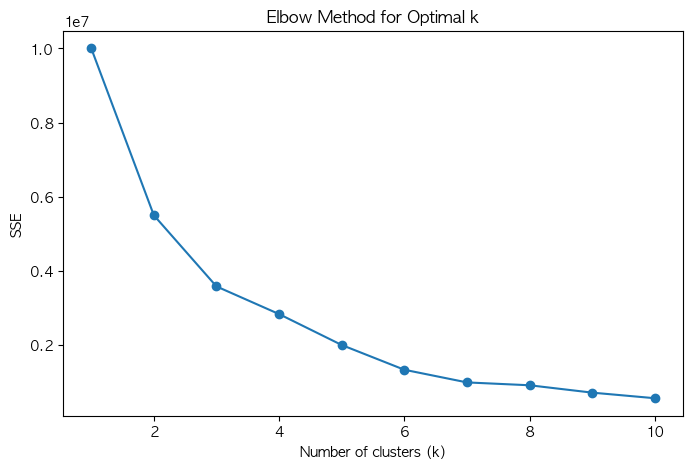

In [60]:
customer_delivery_clean = customer_delivery.dropna(subset=['avg_delivery_days'])
X = customer_delivery_clean[['avg_delivery_days']]

sse = []
k_range = range(1,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal k')
plt.show()

In [62]:
merged_df.tail(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_diff,delivery_status,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,volume_cm3
112645,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,-2.0,제때/조기,...,20.10,bebes,52.0,828.0,4.0,4950.0,40.0,10.0,40.0,16000.0
112646,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,-6.0,제때/조기,...,65.02,eletrodomesticos_2,51.0,500.0,2.0,13300.0,32.0,90.0,22.0,63360.0
112647,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,-21.0,제때/조기,...,40.59,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,8000.0
112648,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,-21.0,제때/조기,...,40.59,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,8000.0
112649,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03,-18.0,제때/조기,...,18.36,beleza_saude,45.0,569.0,1.0,150.0,16.0,7.0,15.0,1680.0


In [63]:
merged_df['delivery_diff'].mean() 

np.float64(-12.030200733238956)

In [66]:
low_core

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_diff,delivery_status
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,fc4af8aea8ec3f1a3cd181d3d0cadbd5,1,NaN,NaN,2017-02-03 00:00:00,2017-02-05 01:58:35,-32,조기
10,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07 00:00:00,15898b543726a832d4137fbef5d1d00e,1,NaN,Aguardando retorno da loja,2017-05-30 00:00:00,2017-05-30 23:13:47,-9,조기
19,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28 00:00:00,38cae21b1b57a95959440380d5b2ef7a,2,NaN,os correios estäo em greve... näo recebi nenhu...,2017-10-01 00:00:00,2017-10-01 17:55:21,11,지연
24,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12 00:00:00,6a1a8e54de03ab98e6e8ff56e56e507f,2,NaN,Demora muito entregar. Já passou o prazo e ain...,2018-03-16 00:00:00,2018-03-20 23:10:58,9,지연
25,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18 00:00:00,2d4303fd561eb4ab51c87faa6598dc10,1,NÃO RECOMENDO!!!!,Até o momento não recebi o produto Protetor De...,2018-06-17 00:00:00,2018-06-20 11:38:22,-32,조기
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99185,41d74f5b8f1fb05bdec674cbba8f720f,960ddf99f2e615bf50ea0cf4e71f526f,delivered,2018-02-04 14:35:02,2018-02-04 14:50:22,2018-02-07 15:35:29,2018-02-15 19:35:37,2018-03-01 00:00:00,7db8262f94491ed7d94f1301b2e91a90,1,NaN,Não gostei imaginei que era uma cortina de tec...,2018-02-16 00:00:00,2018-02-19 09:33:09,-14,조기
99206,38e9133ce29f6bbe35aed9c3863dce01,ad312389a098ceff46ce92c4595c06d0,delivered,2017-10-12 20:54:11,2017-10-14 03:28:24,2017-10-17 17:04:42,2017-11-21 17:06:59,2017-10-31 00:00:00,4a57b77d844594f24904a568218a2d96,1,NaN,nao recebi o produto que ja paguei ! nao recom...,2017-11-03 00:00:00,2017-11-06 18:50:22,21,지연
99208,d692ef54145c9cb3322ec2e5508aa3f4,82ddfcf9438b0cd1117b55ac33184df8,delivered,2018-03-21 19:47:18,2018-03-21 20:05:26,2018-03-22 21:11:58,2018-04-11 00:48:31,2018-04-09 00:00:00,6b2ee488cd87d8a9ee67eb63ad5a7a4c,1,NaN,"Prateleiras com cantos vivo, colunas nao encai...",2018-04-11 00:00:00,2018-04-11 12:41:03,2,지연
99215,cfa78b997e329a5295b4ee6972c02979,a2f7428f0cafbc8e59f20e1444b67315,delivered,2017-12-20 09:52:41,2017-12-20 10:09:52,2017-12-20 20:25:25,2018-01-26 15:45:14,2018-01-18 00:00:00,8ea780895f362ce949029f95b7181ff0,1,NaN,"Ele não é um mini cajon, é um shaker, ou seja,...",2018-01-19 00:00:00,2018-01-21 02:51:39,8,지연


/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_3245/4054889465.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_core[col] = pd.to_datetime(low_core[col], errors='coerce')
/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_3245/4054889465.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_core[col] = pd.to_datetime(low_core[col], errors='coerce')
/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_3245/4054889465.py:10: SettingWithCopyWarning: 
A value is trying to be s

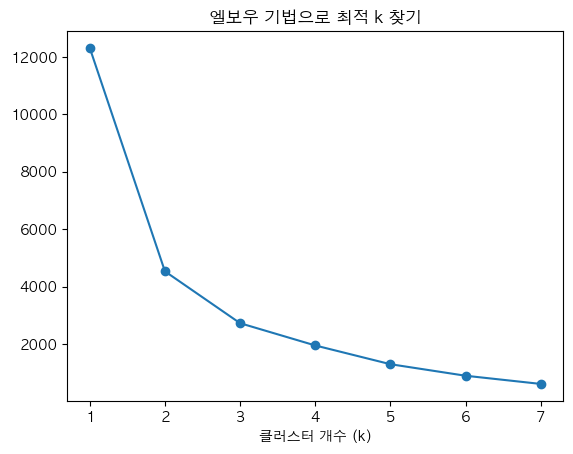

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# === 1) 날짜 컬럼 datetime 변환 ===
date_cols = ['order_delivered_customer_date', 'order_purchase_timestamp']
for col in date_cols:
    low_core[col] = pd.to_datetime(low_core[col], errors='coerce')

# === 2) 배송일 계산 ===
low_core['delivery_days'] = (low_core['order_delivered_customer_date'] - low_core['order_purchase_timestamp']).dt.days

# === 3) 고객별 평균 배송일 계산 ===
customer_delivery = low_core.groupby('customer_id')['delivery_days'].mean().reset_index()

# === 4) NaN 제거 ===
customer_delivery = customer_delivery.dropna()

# === 5) 데이터 스케일링 ===
X = customer_delivery[['delivery_days']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 6) 엘보우 기법으로 최적 k 찾기 ===
inertia = []
K = range(1, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("클러스터 개수 (k)")
plt.title("엘보우 기법으로 최적 k 찾기")
plt.savefig('엘보우로 k 찾기')
plt.show()

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42)
customer_delivery['cluster'] = kmeans.fit_predict(X_scaled)

# === 8) 클러스터별 평균 확인 ===
cluster_summary = customer_delivery.groupby('cluster')['delivery_days'].mean().reset_index()
cluster_summary

,cluster,delivery_days
0,0,9.654695
1,1,51.701741
2,2,27.886235


/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_1563/3435183547.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_summary, x='cluster', y='delivery_days', palette='viridis')


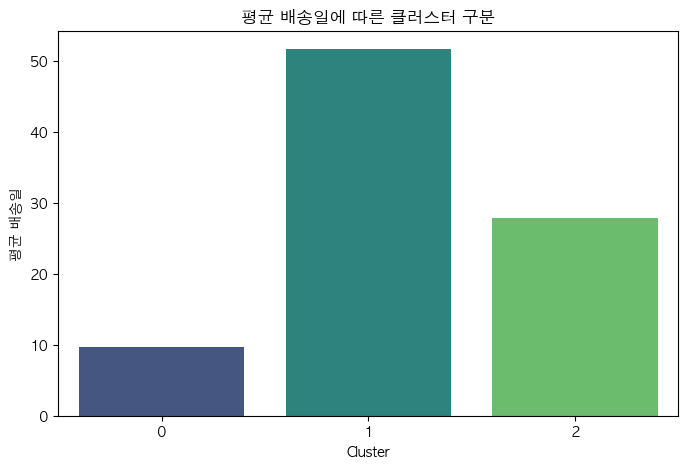

In [93]:
plt.figure(figsize=(8,5))
sns.barplot(data=cluster_summary, x='cluster', y='delivery_days', palette='viridis')

plt.title('평균 배송일에 따른 클러스터 구분')
plt.xlabel('Cluster')
plt.ylabel('평균 배송일')
plt.savefig('클러스터 시각화')
plt.show()

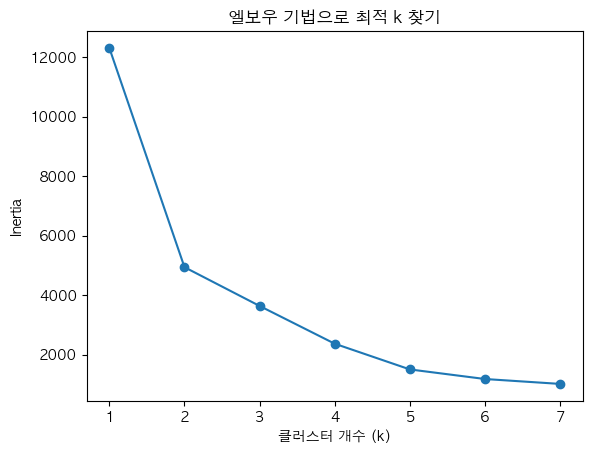

In [73]:
# === 1) 날짜 컬럼 datetime 변환 ===
date_cols = ['order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    low_core[col] = pd.to_datetime(low_core[col], errors='coerce')

# === 2) 배송일 계산 ===
low_core['diff_days'] = (low_core['order_estimated_delivery_date'] - low_core['order_delivered_customer_date']).dt.days

# === 3) 고객별 평균 배송일 계산 ===
customer_delivery_diff = low_core.groupby('customer_id')['diff_days'].mean().reset_index()

# === 4) NaN 제거 ===
customer_delivery_diff = customer_delivery_diff.dropna()

# === 5) 데이터 스케일링 ===
X = customer_delivery_diff[['diff_days']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 6) 엘보우 기법으로 최적 k 찾기 ===
inertia = []
K = range(1, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("클러스터 개수 (k)")
plt.ylabel("Inertia")
plt.title("엘보우 기법으로 최적 k 찾기")
plt.show()

In [74]:
kmeans = KMeans(n_clusters=4, random_state=42)
customer_delivery_diff['cluster'] = kmeans.fit_predict(X_scaled)

# === 8) 클러스터별 평균 확인 ===
print(customer_delivery_diff.groupby('cluster')['diff_days'].mean())

cluster
0     5.537194
1   -11.637192
2    18.164460
3   -49.004237
Name: diff_days, dtype: float64


In [77]:
low_core

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_diff,delivery_status,delivery_days,diff_days
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,fc4af8aea8ec3f1a3cd181d3d0cadbd5,1,NaN,NaN,2017-02-03 00:00:00,2017-02-05 01:58:35,-32,조기,9,31
10,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,15898b543726a832d4137fbef5d1d00e,1,NaN,Aguardando retorno da loja,2017-05-30 00:00:00,2017-05-30 23:13:47,-9,조기,12,8
19,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28,38cae21b1b57a95959440380d5b2ef7a,2,NaN,os correios estäo em greve... näo recebi nenhu...,2017-10-01 00:00:00,2017-10-01 17:55:21,11,지연,21,-12
24,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12,6a1a8e54de03ab98e6e8ff56e56e507f,2,NaN,Demora muito entregar. Já passou o prazo e ain...,2018-03-16 00:00:00,2018-03-20 23:10:58,9,지연,28,-10
25,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18,2d4303fd561eb4ab51c87faa6598dc10,1,NÃO RECOMENDO!!!!,Até o momento não recebi o produto Protetor De...,2018-06-17 00:00:00,2018-06-20 11:38:22,-32,조기,12,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99185,41d74f5b8f1fb05bdec674cbba8f720f,960ddf99f2e615bf50ea0cf4e71f526f,delivered,2018-02-04 14:35:02,2018-02-04 14:50:22,2018-02-07 15:35:29,2018-02-15 19:35:37,2018-03-01,7db8262f94491ed7d94f1301b2e91a90,1,NaN,Não gostei imaginei que era uma cortina de tec...,2018-02-16 00:00:00,2018-02-19 09:33:09,-14,조기,11,13
99206,38e9133ce29f6bbe35aed9c3863dce01,ad312389a098ceff46ce92c4595c06d0,delivered,2017-10-12 20:54:11,2017-10-14 03:28:24,2017-10-17 17:04:42,2017-11-21 17:06:59,2017-10-31,4a57b77d844594f24904a568218a2d96,1,NaN,nao recebi o produto que ja paguei ! nao recom...,2017-11-03 00:00:00,2017-11-06 18:50:22,21,지연,39,-22
99208,d692ef54145c9cb3322ec2e5508aa3f4,82ddfcf9438b0cd1117b55ac33184df8,delivered,2018-03-21 19:47:18,2018-03-21 20:05:26,2018-03-22 21:11:58,2018-04-11 00:48:31,2018-04-09,6b2ee488cd87d8a9ee67eb63ad5a7a4c,1,NaN,"Prateleiras com cantos vivo, colunas nao encai...",2018-04-11 00:00:00,2018-04-11 12:41:03,2,지연,20,-3
99215,cfa78b997e329a5295b4ee6972c02979,a2f7428f0cafbc8e59f20e1444b67315,delivered,2017-12-20 09:52:41,2017-12-20 10:09:52,2017-12-20 20:25:25,2018-01-26 15:45:14,2018-01-18,8ea780895f362ce949029f95b7181ff0,1,NaN,"Ele não é um mini cajon, é um shaker, ou seja,...",2018-01-19 00:00:00,2018-01-21 02:51:39,8,지연,37,-9


In [85]:
low_core["order_purchase_timestamp"] = pd.to_datetime(low_core["order_purchase_timestamp"])
low_core["order_delivered_carrier_date"] = pd.to_datetime(low_core["order_delivered_carrier_date"])

# 주문 ~ 발송 일수 계산
low_core["purchase_to_ship_days"] = (
    low_core["order_delivered_carrier_date"] - low_core["order_purchase_timestamp"]
).dt.days

# 결측치 제거 (발송일 없는 경우 제외)
low_core = low_core.dropna(subset=["purchase_to_ship_days"])

# 고객별 평균 주문~발송 일수
customer_avg_ship = (
    low_core.groupby("customer_id")["purchase_to_ship_days"]
    .mean()
    .reset_index()
)

customer_avg_ship['purchase_to_ship_days'].mean()

np.float64(4.0822640896540525)

In [102]:
orders_df["order_purchase_timestamp"] = pd.to_datetime(orders_df["order_purchase_timestamp"])
orders_df["order_delivered_carrier_date"] = pd.to_datetime(orders_df["order_delivered_carrier_date"])

# 주문 ~ 발송 일수 계산
orders_df["purchase_to_ship_days"] = (
    orders_df["order_delivered_carrier_date"] - orders_df["order_purchase_timestamp"]
).dt.days

# 결측치 제거 (발송일 없는 경우 제외)
orders_df = orders_df.dropna(subset=["purchase_to_ship_days"])

# 고객별 평균 주문~발송 일수
customer_avg_shipment = (
    orders_df.groupby("customer_id")["purchase_to_ship_days"]
    .mean()
    .reset_index()
)

customer_avg_shipment['purchase_to_ship_days'].mean()

np.float64(2.7431137234020766)

In [103]:
customer_avg_shipment

,customer_id,purchase_to_ship_days
0,00012a2ce6f8dcda20d059ce98491703,2.0
1,000161a058600d5901f007fab4c27140,3.0
2,0001fd6190edaaf884bcaf3d49edf079,1.0
3,0002414f95344307404f0ace7a26f1d5,2.0
4,000379cdec625522490c315e70c7a9fb,2.0
...,...,...
97653,fffcb937e9dd47a13f05ecb8290f4d3e,0.0
97654,fffecc9f79fd8c764f843e9951b11341,1.0
97655,fffeda5b6d849fbd39689bb92087f431,2.0
97656,ffff42319e9b2d713724ae527742af25,2.0


In [106]:
!pip install geopandas

import geopandas as gpd
import matplotlib as mpl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 8.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 9.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]


/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_1563/3496479675.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('OrRd')


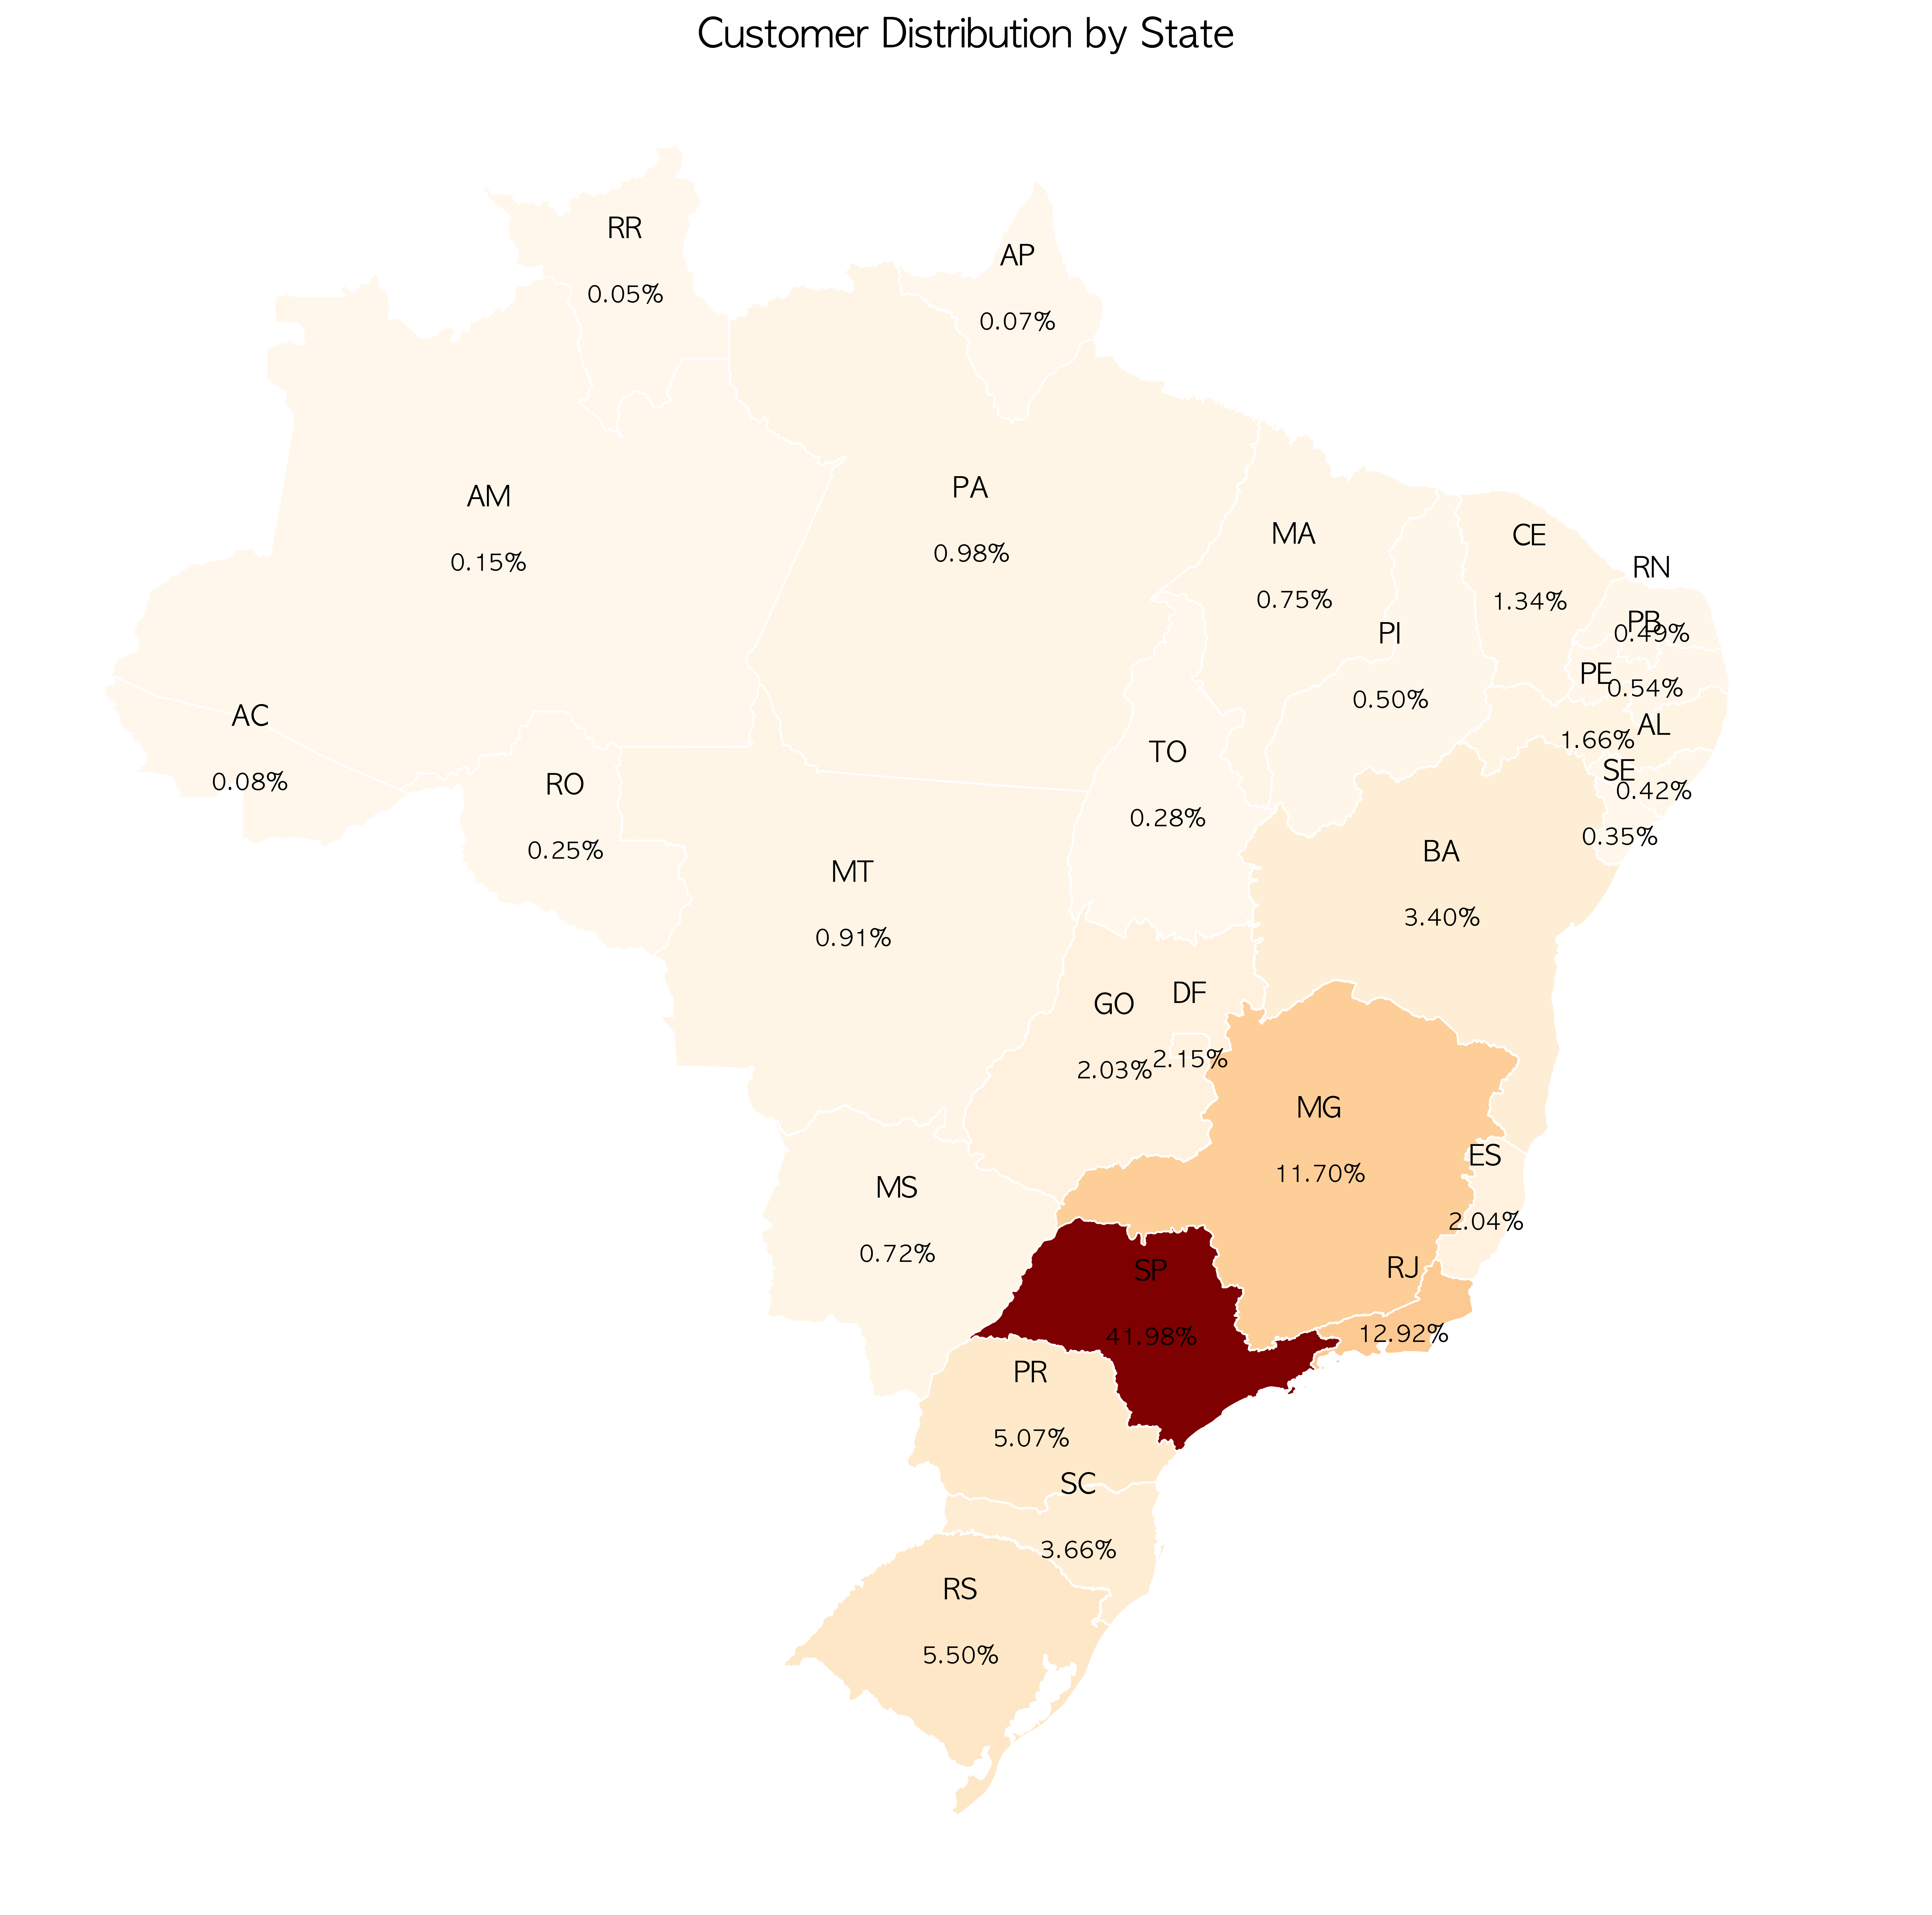

In [109]:
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brazil = gpd.read_file(url).rename(columns={'sigla': 'state'})


customer_data = pd.DataFrame({
    'state': ['SP', 'RJ', 'MG', 'RS', 'PR', 'SC', 'BA', 'DF', 'ES', 'GO', 'PE', 'CE', 'PA', 'MT',
              'MA', 'MS', 'PB', 'PI', 'RN', 'AL', 'SE', 'TO', 'RO', 'AM', 'AC', 'AP', 'RR'],
    'customer_count': [41746, 12852, 11635, 5466, 5045, 3637, 3380, 2140, 2033, 2020, 1652, 1336,
                       975, 907, 747, 715, 536, 495, 485, 413, 350, 280, 253, 148, 81, 68, 46]
})

# 4️⃣ 고객 비율 계산 및 GeoDataFrame 병합
# ===============================================
total = customer_data['customer_count'].sum()
customer_data['percentage'] = customer_data['customer_count'] / total * 100

merged = brazil.merge(customer_data, on='state', how='left')

# ===============================================
# 5️⃣ 지도 시각화
# ===============================================
fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=600)

# 배경 회색
brazil.plot(ax=ax, color='#EEEEEE', edgecolor='white')

# 고객 데이터 있는 주만 색칠
merged_with_data = merged[merged['customer_count'] > 0]
cmap = mpl.cm.get_cmap('OrRd')
norm = mpl.colors.Normalize(vmin=merged_with_data['customer_count'].min(),
                            vmax=merged_with_data['customer_count'].max())
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

merged_with_data.plot(
    column='customer_count',
    cmap=cmap,
    linewidth=0.8,
    edgecolor='white',
    ax=ax
)

# 텍스트 (주코드 + 비율)
for idx, row in merged_with_data.iterrows():
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y + 1.0, row['state'], fontsize=12, ha='center', weight='bold')
    ax.text(centroid.x, centroid.y - 0.5, f"{row['percentage']:.2f}%", fontsize=10, ha='center')


# 제목 및 축 제거
plt.title("Customer Distribution by State", fontsize=17)
ax.axis('off')

# 저장 및 출력
plt.savefig("customer_distribution.png", dpi=600, bbox_inches='tight')
plt.show()

In [111]:
geolocation_df

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


In [112]:
orders_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_diff,delivery_status,purchase_to_ship_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,제때/조기,2
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,제때/조기,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,제때/조기,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,제때/조기,3
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,제때/조기,0
...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,-11.0,제때/조기,1
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,-2.0,제때/조기,1
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,-6.0,제때/조기,1
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,-21.0,제때/조기,3


In [115]:
customers_df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [117]:
orders_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_diff,delivery_status,purchase_to_ship_days,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,제때/조기,2,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,제때/조기,1,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,제때/조기,0,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,제때/조기,3,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,제때/조기,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,-11.0,제때/조기,1,8.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,-2.0,제때/조기,1,22.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,-6.0,제때/조기,1,24.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,-21.0,제때/조기,3,17.0


/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_1563/4190890557.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('viridis', 3)  # 3개의 군집


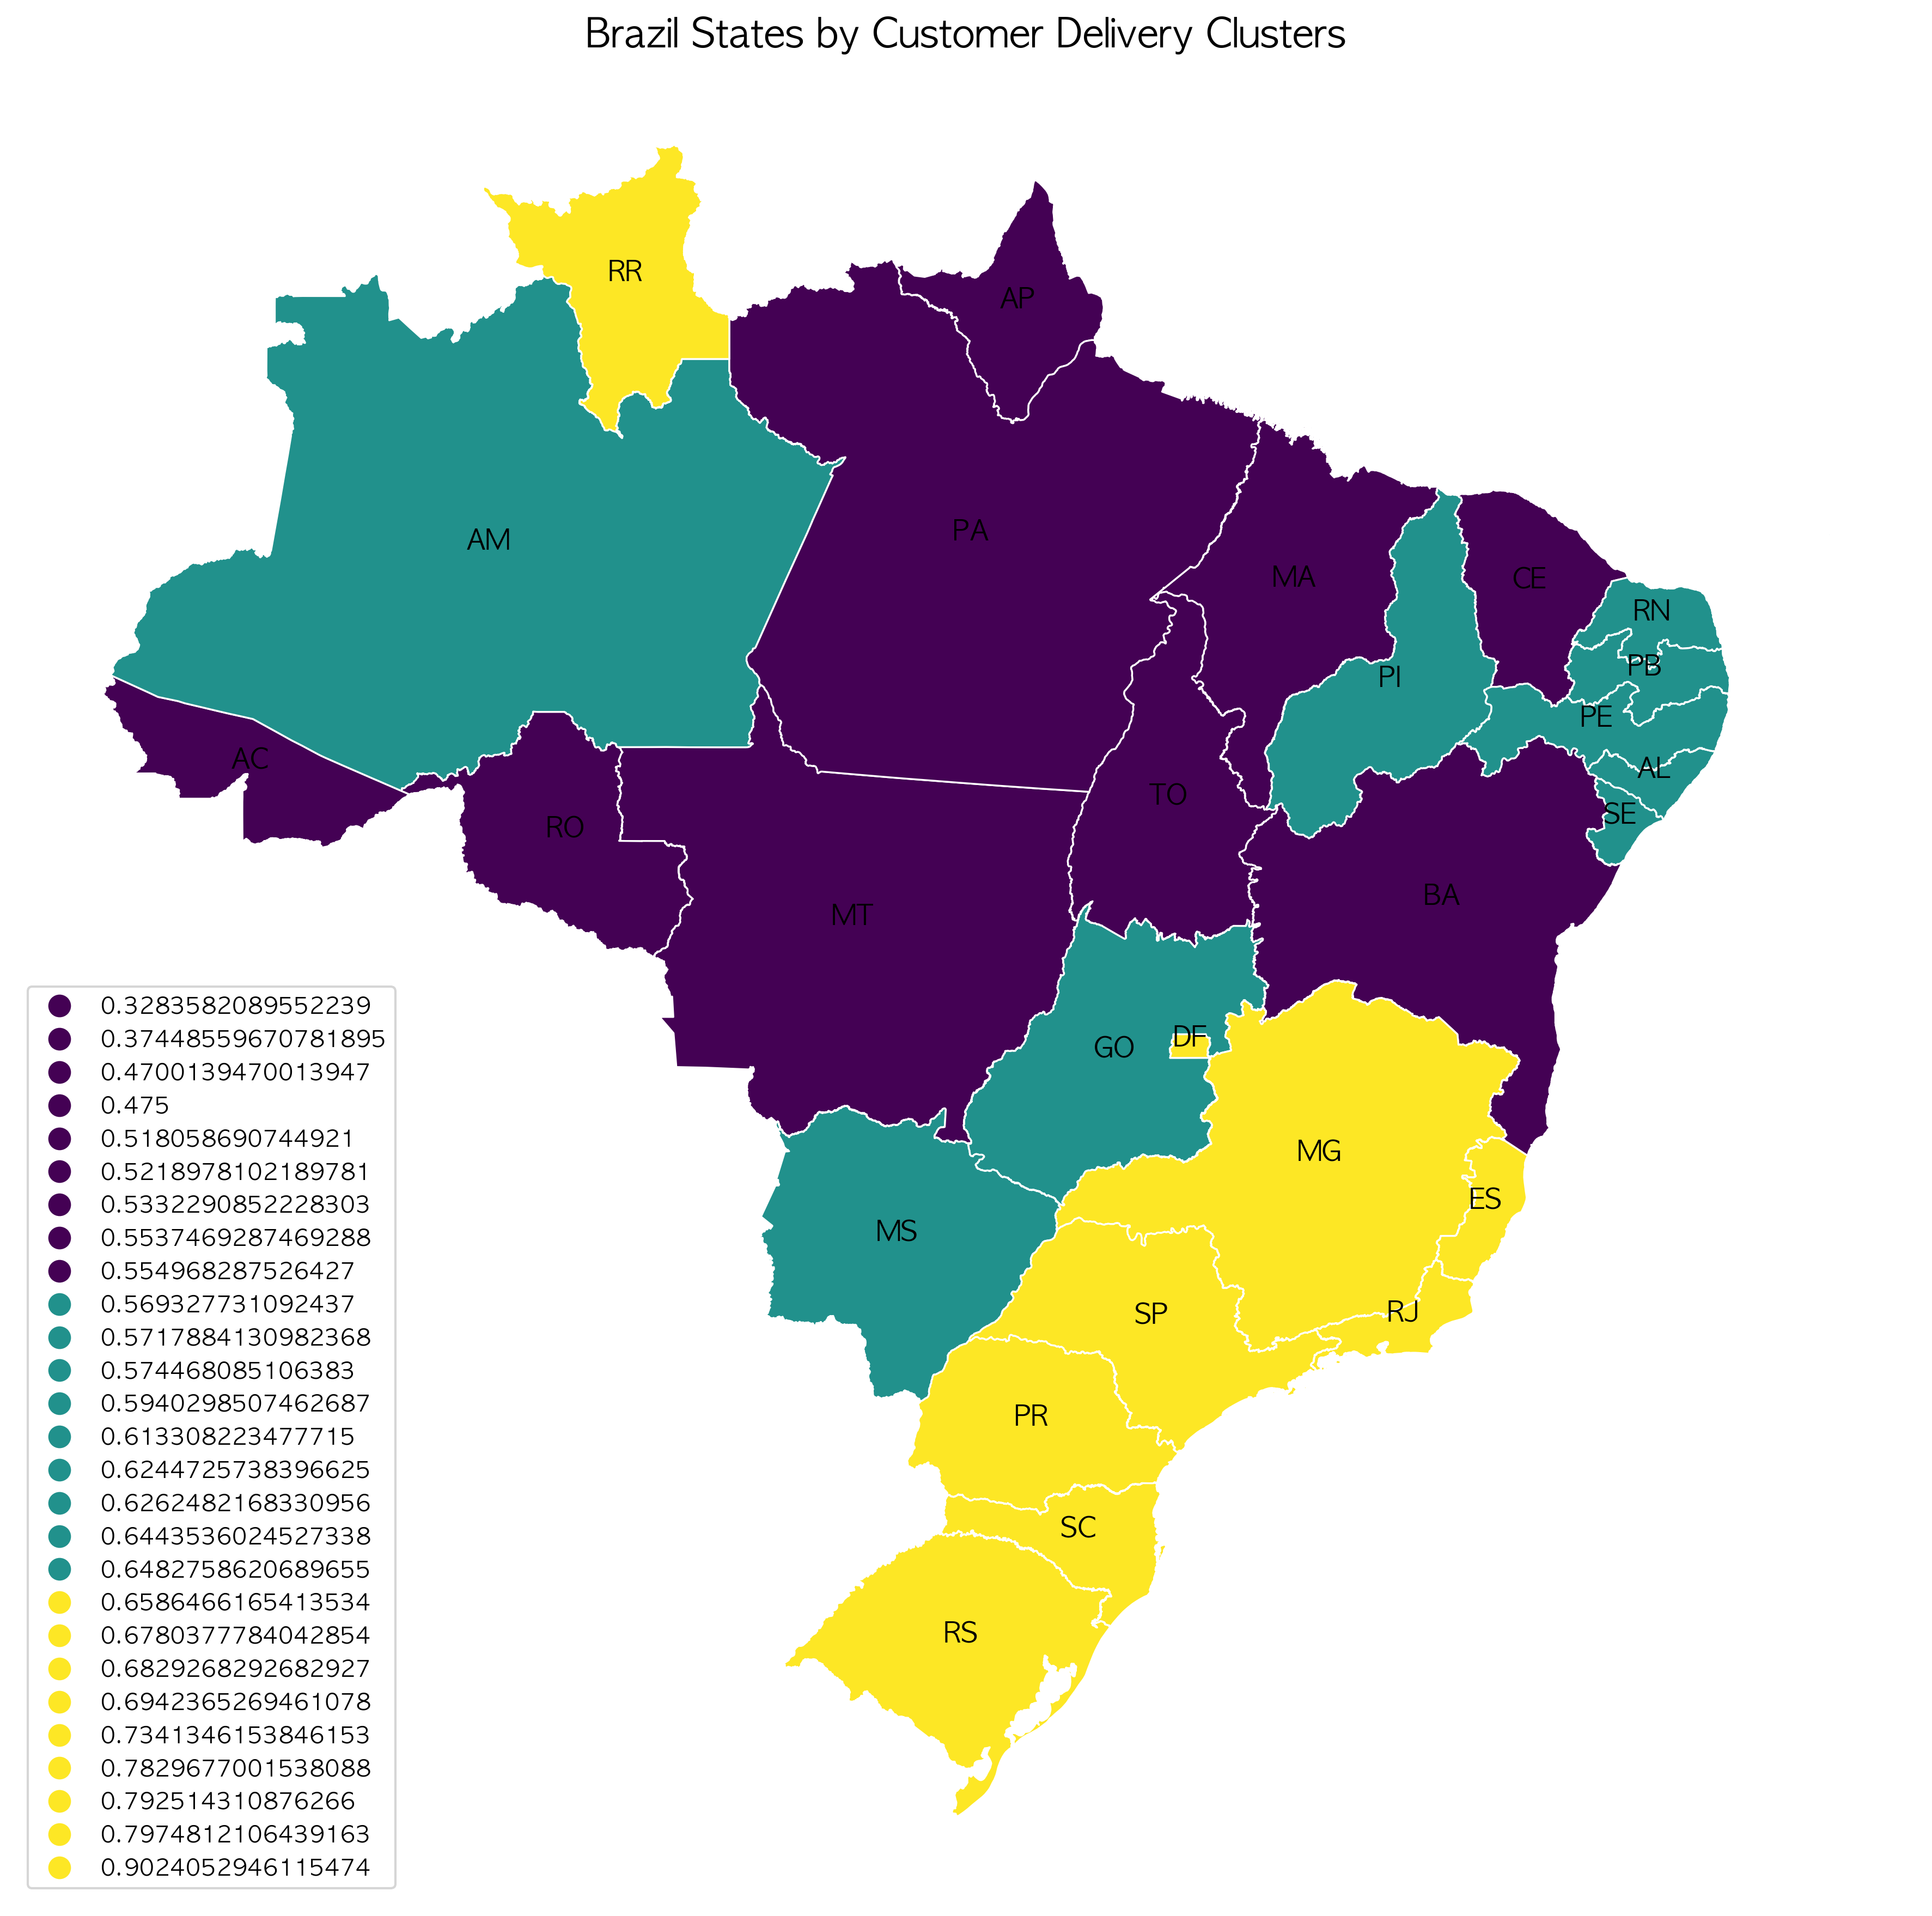

In [122]:
# ===============================
# 1️⃣ GeoJSON 브라질 경계 불러오기
# ===============================
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brazil = gpd.read_file(url).rename(columns={'sigla': 'state'})

# ===============================
# 2️⃣ orders_df + customer_df 병합
# ===============================
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])

orders_with_state = orders_df.merge(
    customers_df[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

# ===============================
# 3️⃣ 배송일 계산 및 고객별 평균 배송일
# ===============================
orders_with_state['delivery_days'] = (
    orders_with_state['order_delivered_customer_date'] - 
    orders_with_state['order_purchase_timestamp']
).dt.days

customer_delivery = orders_with_state.groupby(
    ['customer_id', 'customer_state']
)['delivery_days'].mean().reset_index()

customer_delivery = customer_delivery.dropna()

# ===============================
# 4️⃣ KMeans 군집화 (3군집)
# ===============================
X = customer_delivery[['delivery_days']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
customer_delivery['cluster'] = kmeans.fit_predict(X_scaled)

# ===============================
# 5️⃣ state별 평균 클러스터 계산
# ===============================
state_cluster = customer_delivery.groupby('customer_state')['cluster'].mean().reset_index()
state_cluster = state_cluster.rename(columns={'customer_state':'state'})

# ===============================
# 6️⃣ GeoDataFrame과 병합
# ===============================
merged = brazil.merge(state_cluster, on='state', how='left')

# ===============================
# 7️⃣ 지도 시각화 (클러스터 색상)
# ===============================
fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=300)

# 회색 배경
brazil.plot(ax=ax, color='#EEEEEE', edgecolor='white')

# 클러스터 있는 주만 색칠
merged_with_data = merged[~merged['cluster'].isna()]

cmap = mpl.cm.get_cmap('viridis', 3)  # 3개의 군집
merged_with_data.plot(
    column='cluster',
    cmap=cmap,
    linewidth=0.8,
    edgecolor='white',
    ax=ax,
    legend=True,
    categorical=True
)

# 텍스트로 주 코드 표시
for idx, row in merged_with_data.iterrows():
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y, row['state'], fontsize=12, ha='center', weight='bold')

plt.title("Brazil States by Customer Delivery Clusters", fontsize=17)
ax.axis('off')
plt.show()

/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_3245/1191827810.py:98: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('viridis', 3)


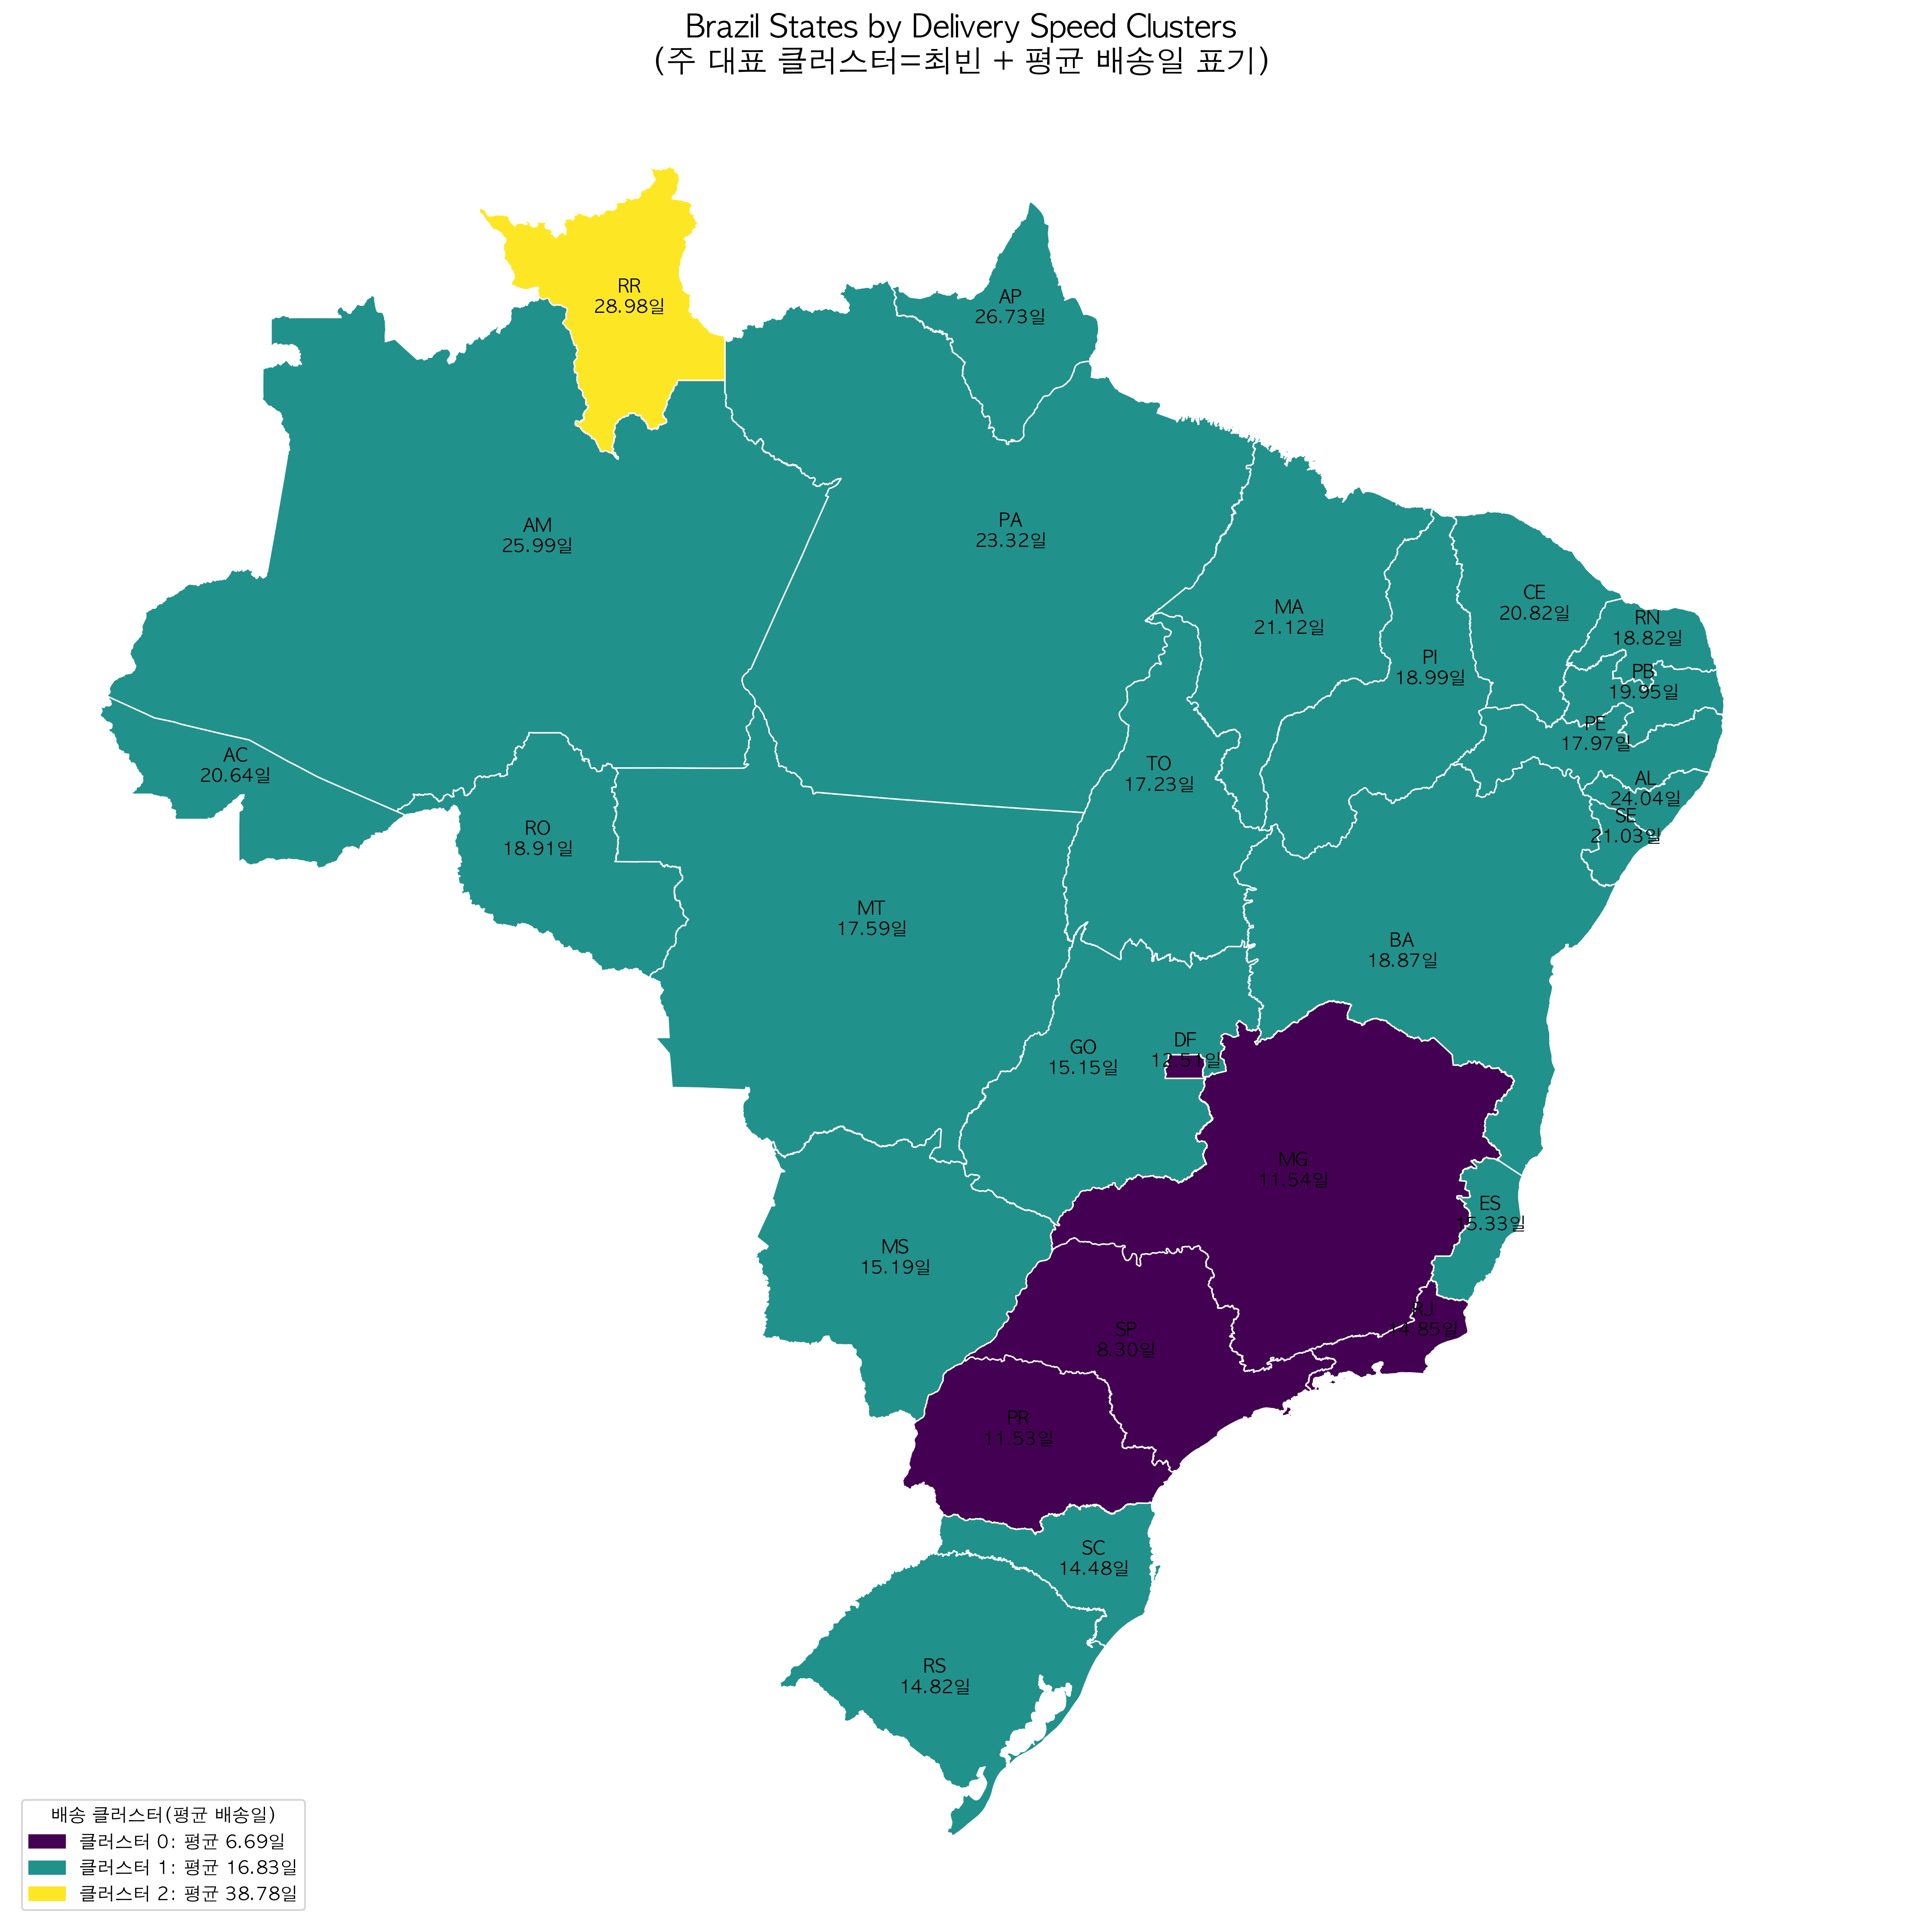

In [17]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ===============================
# 0) 브라질 주 경계 (두 글자 주코드: 'state')
# ===============================
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brazil = gpd.read_file(url).rename(columns={'sigla': 'state'})

# ===============================
# 1) 날짜 컬럼 변환 + 배송일 계산 (orders_df)
# ===============================
orders = orders_df.copy()
for col in ['order_purchase_timestamp', 'order_delivered_customer_date']:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# 고객별 평균 배송일
customer_delivery = (
    orders.groupby('customer_id', as_index=False)['delivery_days']
          .mean()
          .dropna(subset=['delivery_days'])
)

# ===============================
# 2) 고객 → 주(state) 붙이기 (customer_df)
# ===============================
id_state = (
    customers_df[['customer_id', 'customer_state']]
    .dropna()
    .drop_duplicates()
)

cd_with_state = customer_delivery.merge(id_state, on='customer_id', how='left')
cd_with_state = cd_with_state.dropna(subset=['customer_state'])

# ===============================
# 3) KMeans(3)로 고객 클러스터링
# ===============================
X = cd_with_state[['delivery_days']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
cd_with_state['cluster'] = kmeans.fit_predict(X_scaled)

# ===============================
# 4) 클러스터별 평균 배송일(범례용, 둘째자리)
# ===============================
cluster_summary = (
    cd_with_state.groupby('cluster')['delivery_days']
    .mean()
    .reset_index()
)

# ===============================
# 5) 주(state) 단위 집계
#    - 대표 클러스터: 최빈값(mode)
#    - 평균 배송일: mean
# ===============================
def mode_cluster(s):
    return s.value_counts().idxmax()

state_agg = (
    cd_with_state.groupby('customer_state')
    .agg(
        state_cluster=('cluster', mode_cluster),
        avg_delivery_days=('delivery_days', 'mean'),
        n_customers=('customer_id', 'nunique')
    )
    .reset_index()
    .rename(columns={'customer_state': 'state'})
)

# ===============================
# 6) 지오데이터 병합
# ===============================
merged = brazil.merge(state_agg, on='state', how='left')
merged_with_data = merged[~merged['state_cluster'].isna()].copy()

# ===============================
# 7) 지도 시각화 (3그룹 색상 + 평균일자 텍스트 + 범례)
# ===============================
fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=300)

# 회색 베이스
brazil.plot(ax=ax, color='#EEEEEE', edgecolor='white')

# 색칠
cmap = mpl.cm.get_cmap('viridis', 3)
merged_with_data.plot(
    column='state_cluster',
    cmap=cmap,
    linewidth=0.8,
    edgecolor='white',
    ax=ax,
    legend=False,
    categorical=True
)

# 주 코드 + 평균 배송일(둘째자리) 텍스트
for _, row in merged_with_data.iterrows():
    rep_pt = row['geometry'].representative_point()
    ax.text(
        rep_pt.x, rep_pt.y,
        f"{row['state']}\n{row['avg_delivery_days']:.2f}일",
        fontsize=10, ha='center', weight='bold'
    )

# 커스텀 범례: "클러스터 n: 평균 XX.XX일"
handles = []
N = 3
for _, r in cluster_summary.iterrows():
    c = int(r['cluster'])
    color = cmap(c/(N-1))   # 0,1,2 → 0.0, 0.5, 1.0
    handles.append(
        mpatches.Patch(
            color=color,
            label=f"클러스터 {c}: 평균 {r['delivery_days']:.2f}일"
        )
    )
ax.legend(handles=handles, title="배송 클러스터(평균 배송일)", loc='lower left')

plt.title("Brazil States by Delivery Speed Clusters\n(주 대표 클러스터=최빈 + 평균 배송일 표기)", fontsize=17)
ax.axis('off')
plt.tight_layout()
plt.show()


/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_3245/408342562.py:144: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('viridis', 3)


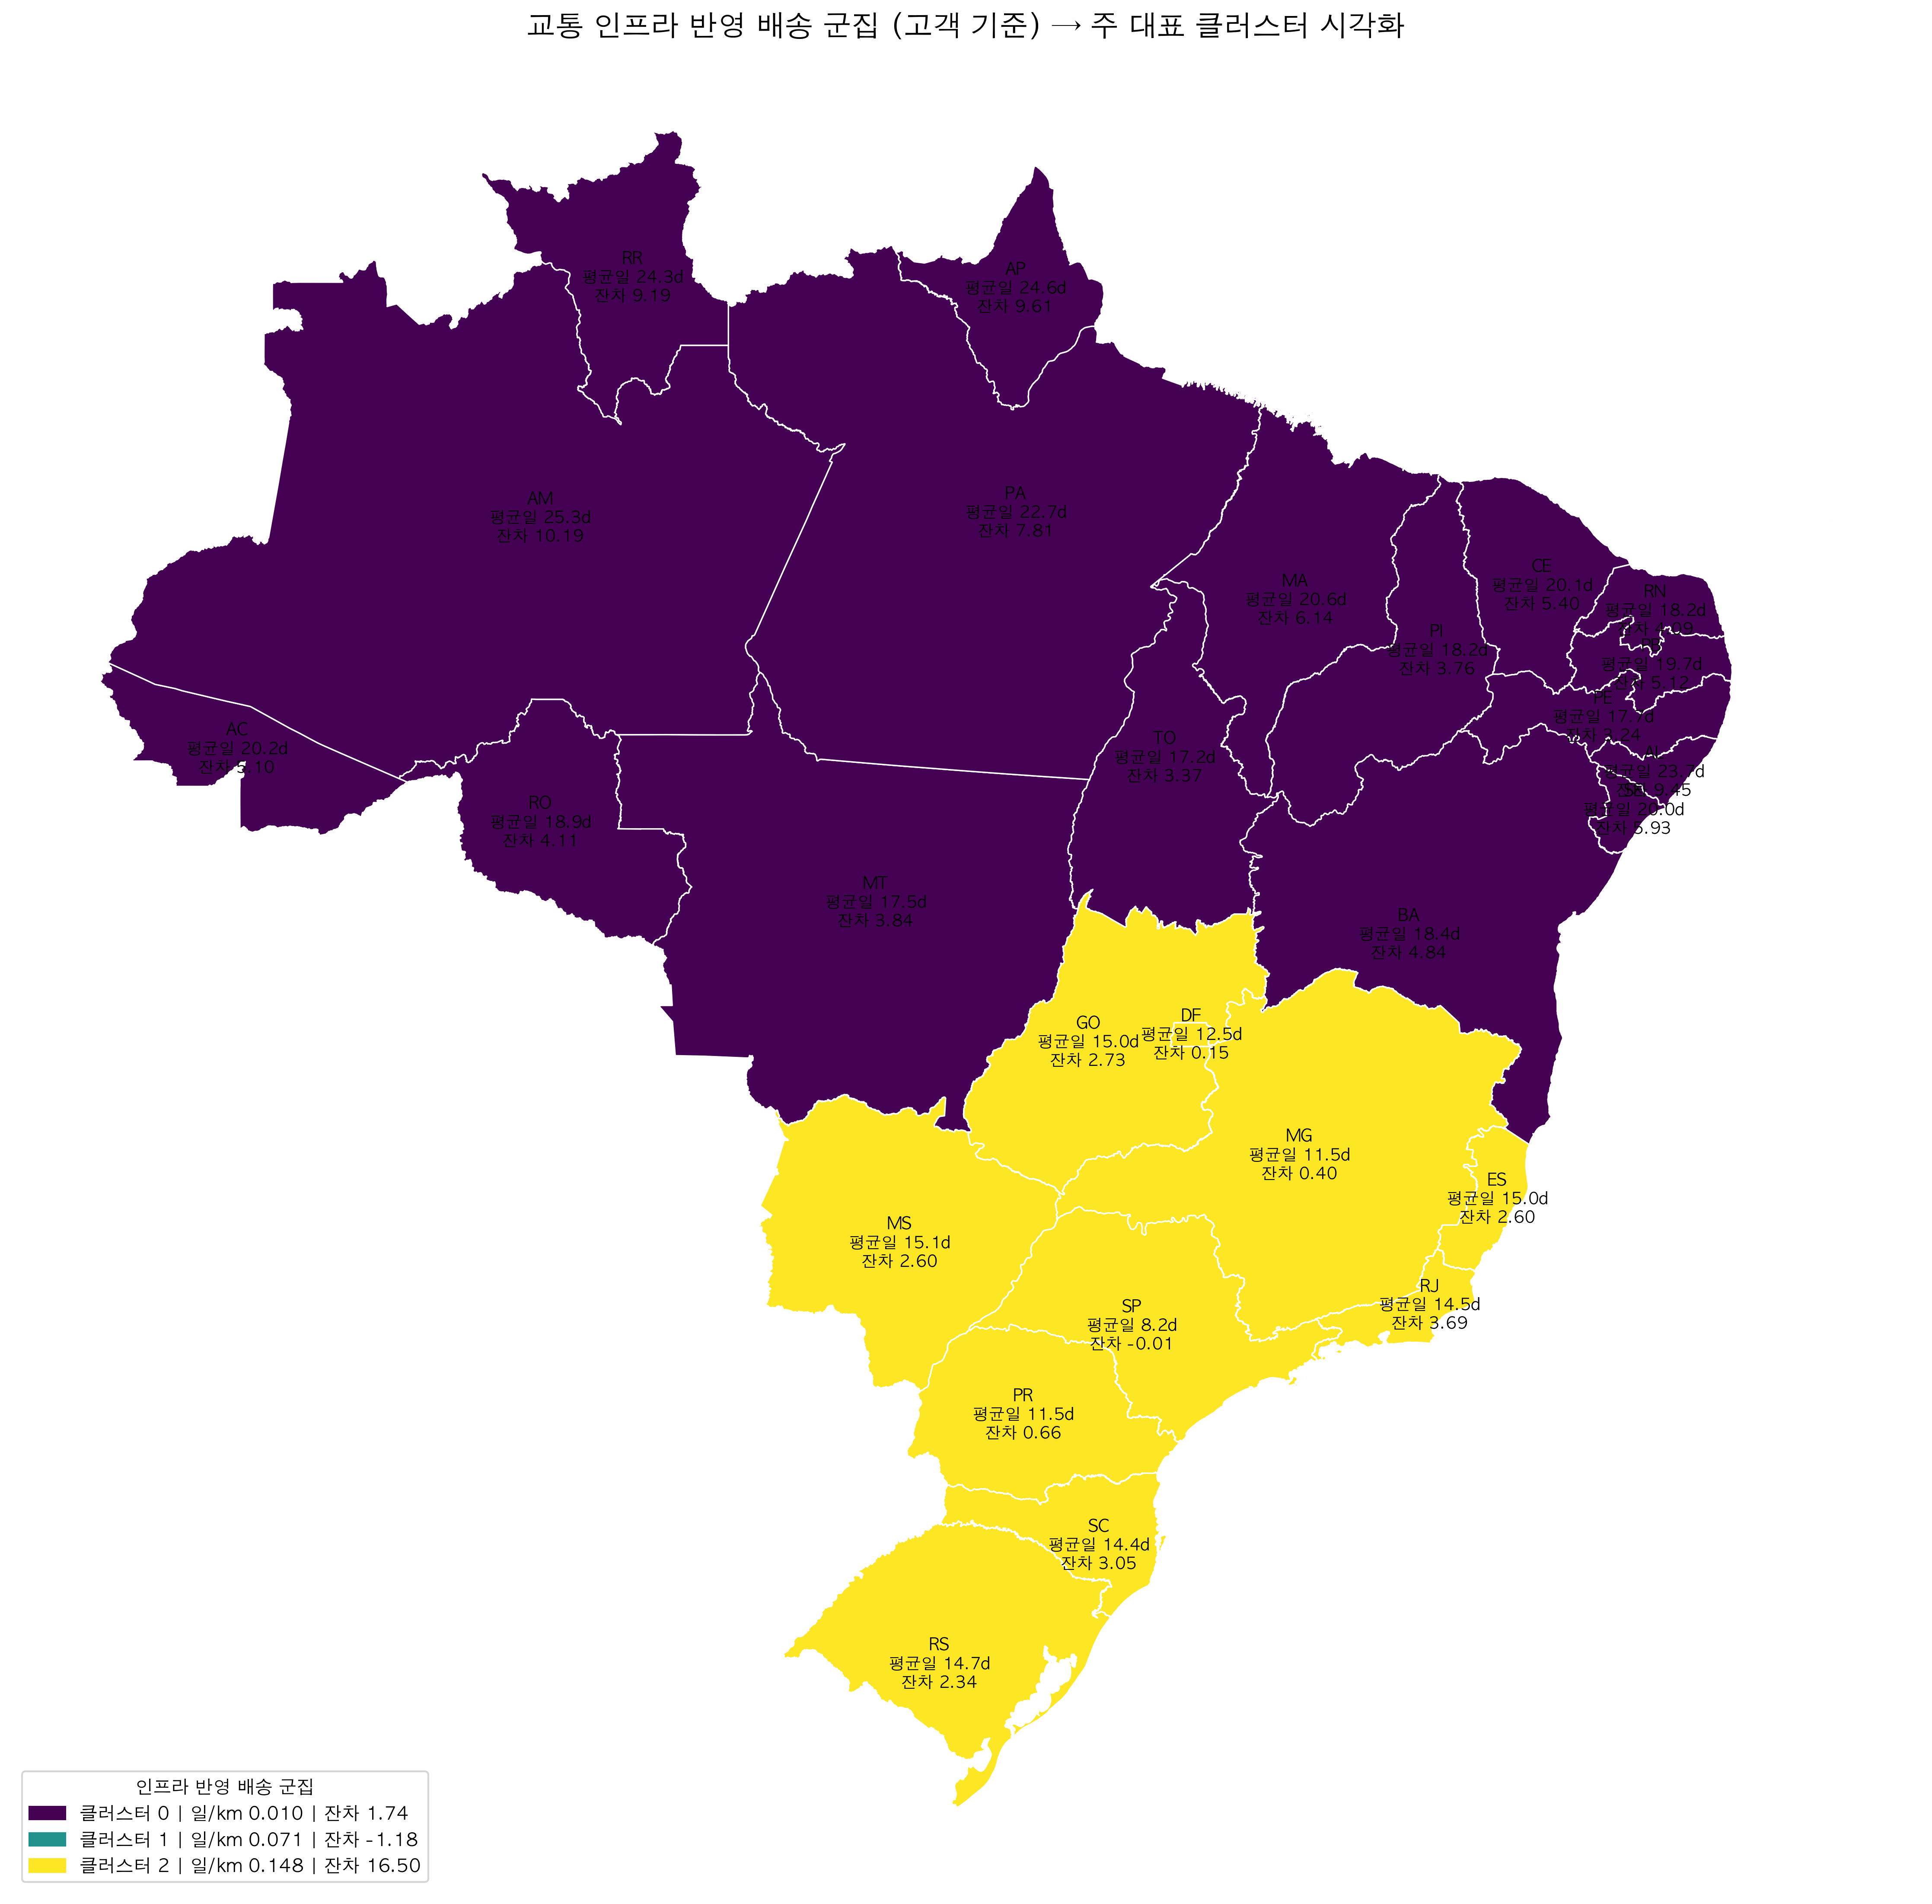

In [19]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import HuberRegressor  # 튼튼한(robust) 회귀
from math import radians, sin, cos, asin, sqrt

# ---------------------------
# 0) Geo: 브라질 주 경계
# ---------------------------
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brazil = gpd.read_file(url).rename(columns={'sigla': 'state'})

# ---------------------------
# 1) 준비: 날짜/좌표/거리
# ---------------------------
orders = orders_df.copy()
for col in ['order_purchase_timestamp', 'order_delivered_customer_date']:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# 배송일수
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# 좌표 준비 (geolocation_df: zip_code_prefix, geolocation_lat, geolocation_lng)
geo = geolocation_df.drop_duplicates('geolocation_zip_code_prefix').rename(
    columns={'geolocation_zip_code_prefix':'zip_prefix',
             'geolocation_lat':'lat',
             'geolocation_lng':'lng'}
)

cust = customers_df.rename(columns={'customer_zip_code_prefix':'zip_prefix'})
sell = sellers_df.rename(columns={'seller_zip_code_prefix':'zip_prefix'})

cust_xy = cust.merge(geo, on='zip_prefix', how='left') \
              .rename(columns={'lat':'cust_lat','lng':'cust_lng'}) \
              [['customer_id','customer_state','cust_lat','cust_lng']]

sell_xy = sell.merge(geo, on='zip_prefix', how='left') \
              .rename(columns={'lat':'sell_lat','lng':'sell_lng'}) \
              [['seller_id','sell_lat','sell_lng']]

# 주문-셀러 매핑 (한 주문에 다수 셀러 → 평균거리로 대표)
oi = items_df[['order_id','seller_id']].drop_duplicates()
oi = oi.merge(sell_xy, on='seller_id', how='left')

# 고객 좌표 붙이기
ord_base = orders[['order_id','customer_id','delivery_days']].merge(cust_xy, on='customer_id', how='left')
od = oi.merge(ord_base, on='order_id', how='left')

# Haversine (km)
def haversine(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return np.nan
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2*R*asin(sqrt(a))

od['distance_km'] = od.apply(lambda r: haversine(r['cust_lat'], r['cust_lng'], r['sell_lat'], r['sell_lng']), axis=1)

# 주문 단위 대표 거리(여러 셀러면 평균)
order_dist = od.groupby('order_id', as_index=False)['distance_km'].mean()

# 주문 수준 테이블
order_level = orders[['order_id','customer_id','delivery_days']].merge(order_dist, on='order_id', how='left') \
                .merge(cust_xy[['customer_id','customer_state']], on='customer_id', how='left')

# 노이즈/결측 정리
order_level = order_level.dropna(subset=['delivery_days','distance_km','customer_state'])
order_level = order_level[(order_level['delivery_days']>=0) & (order_level['distance_km']>=0)]
# 극단값 클리핑(상위 1% 컷)
order_level['delivery_days'] = order_level['delivery_days'].clip(upper=order_level['delivery_days'].quantile(0.99))
order_level['distance_km']   = order_level['distance_km'].clip(upper=order_level['distance_km'].quantile(0.99))

# ---------------------------
# 2) 인프라 반영 지표 만들기
#   (A) 효율지표: 일/킬로미터
#   (B) 잔차지표: 거리로 예측한 기대일수 대비 초과/미달
# ---------------------------
order_level['efficiency'] = order_level['delivery_days'] / (order_level['distance_km'] + 1.0)

# (B) Robust 회귀로 기대 배송일수 추정 → 잔차
X = np.log1p(order_level[['distance_km']].values)  # 거리 로그 스케일이 보통 적합
y = order_level['delivery_days'].values
hub = HuberRegressor().fit(X, y)
order_level['expected_days'] = hub.predict(X)
order_level['infra_residual'] = order_level['delivery_days'] - order_level['expected_days']
# (+) 값 클수록 거리로 설명 안되는 추가지연(=인프라/운영 취약), (−)면 효율적

# ---------------------------
# 3) 고객 기준/주 기준 집계
# ---------------------------
# 고객 평균 (원래 하시던 단위 유지)
cust_feat = order_level.groupby(['customer_id','customer_state'], as_index=False) \
    .agg(delivery_days_mean=('delivery_days','mean'),
         distance_km_mean=('distance_km','mean'),
         efficiency_mean=('efficiency','mean'),
         infra_resid_mean=('infra_residual','mean'))

# 주 단위 특징 (지도용)
state_feat = order_level.groupby('customer_state', as_index=False) \
    .agg(avg_delivery_days=('delivery_days','mean'),
         avg_distance_km=('distance_km','mean'),
         avg_efficiency=('efficiency','mean'),
         avg_infra_resid=('infra_residual','mean'),
         n_orders=('order_id','nunique'))

# ---------------------------
# 4) KMeans (교통 인프라 반영)
#    - 고객 기준 군집: efficiency_mean, infra_resid_mean 포함
# ---------------------------
feat_cols = ['delivery_days_mean','distance_km_mean','efficiency_mean','infra_resid_mean']
Xc = cust_feat[feat_cols].values
scaler = StandardScaler()
Xc_scaled = scaler.fit_transform(Xc)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cust_feat['cluster'] = kmeans.fit_predict(Xc_scaled)

# 주 대표 클러스터 = 최빈
state_mode = cust_feat.groupby('customer_state')['cluster'].agg(lambda s: s.value_counts().idxmax()).reset_index()
state_mode = state_mode.rename(columns={'customer_state':'state','cluster':'state_cluster'})

# 범례용: 클러스터별 평균 지표
cluster_summary = cust_feat.groupby('cluster')[feat_cols].mean().reset_index()

# ---------------------------
# 5) 지도 병합 & 시각화
# ---------------------------
merged = brazil.merge(state_feat.rename(columns={'customer_state':'state'}), on='state', how='left') \
               .merge(state_mode, on='state', how='left')
plot_df = merged[~merged['state_cluster'].isna()].copy()

fig, ax = plt.subplots(1,1,figsize=(15,15), dpi=300)
brazil.plot(ax=ax, color='#EEEEEE', edgecolor='white')

cmap = mpl.cm.get_cmap('viridis', 3)
plot_df.plot(column='state_cluster', cmap=cmap, edgecolor='white', linewidth=0.8,
             ax=ax, legend=False, categorical=True)

# 주 코드 + 인프라잔차(평균) 표기
for _, r in plot_df.iterrows():
    pt = r.geometry.representative_point()
    ax.text(pt.x, pt.y,
            f"{r['state']}\n평균일 {r['avg_delivery_days']:.1f}d\n잔차 {r['avg_infra_resid']:.2f}",
            ha='center', va='center', fontsize=9, weight='bold')

# 커스텀 범례 (cluster별 효율/잔차 평균)
handles=[]
N=3
for _, row in cluster_summary.iterrows():
    c = int(row['cluster'])
    color = cmap(c/(N-1))
    label = (f"클러스터 {c} | 일/km {row['efficiency_mean']:.3f} | "
             f"잔차 {row['infra_resid_mean']:.2f}")
    handles.append(mpatches.Patch(color=color, label=label))
ax.legend(handles=handles, title="인프라 반영 배송 군집", loc='lower left')

plt.title("교통 인프라 반영 배송 군집 (고객 기준) → 주 대표 클러스터 시각화", fontsize=16)
ax.axis('off'); plt.tight_layout(); plt.show()
